# Filter Methods: Fisher Score for Class Separation

### 1. Clear Overview
The **Fisher Score** is a classic, effective filter method designed specifically for **classification problems**. It evaluates a feature's discriminative power by measuring how well its values separate different classes. 

A high Fisher Score indicates that the feature has distinct mean values across classes while maintaining low variance within each class—a hallmark of a high-quality predictive feature.

### 2. Theory: The Discriminative Logic
The Fisher Score balances two critical statistical properties:
* **Between-Class Variance:** The distance between the means of different classes. (Larger = Better separation).
* **Within-Class Variance:** The dispersion (spread) of values within each class. (Smaller = More consistent signal).

**Formula (Binary Classification):**
$$ Fisher\ Score = \frac{(\mu_0 - \mu_1)^2}{\sigma_0^2 + \sigma_1^2} $$

*Where $\mu$ represents the mean and $\sigma^2$ represents the variance for Class 0 and Class 1.*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

### 3. Generating Synthetic Data
We will generate a binary classification dataset with three distinct features to demonstrate how the Fisher Score evaluates them:
1. **Good Feature**: Means are far apart, variances are tight.
2. **Bad Feature**: Means are almost identical, variances are high.
3. **Complex Feature**: Means are identical, but the distributions are distinct (one is bimodal/skewed). This tests the limitation of the Fisher Score.

In [2]:
np.random.seed(42)
n_samples = 1000

# Target Variable: Class 0 vs Class 1
y = np.random.choice([0, 1], size=n_samples)

# 1. Good Feature (High between-class variance, low within-class variance)
feat_good = np.where(y == 0, np.random.normal(2, 1, n_samples), np.random.normal(7, 1.5, n_samples))

# 2. Bad Feature (Noisy, completely overlapping)
feat_bad = np.where(y == 0, np.random.normal(5, 3, n_samples), np.random.normal(5.2, 3, n_samples))

# 3. Complex Feature (Same mean, different distributions - e.g., overlapping standard vs tight variance)
# Both have mean ~0, but class 1 has massive variance while class 0 is tight
feat_complex = np.where(y == 0, np.random.normal(0, 0.5, n_samples), np.random.normal(0, 5, n_samples))

df = pd.DataFrame({
    'Good_Feature': feat_good,
    'Bad_Feature': feat_bad,
    'Complex_Feature': feat_complex,
    'Target': y
})

### 4. Custom Python Implementation
Scikit-learn does not have a native `fisher_score` API for continuous variables, so we implement it mathematically.

In [3]:
def calculate_fisher_score(df, feature, target):
    """Calculates the Fisher Score for a continuous feature in a binary classification task."""
    # Split data by class
    class_0 = df[df[target] == 0][feature]
    class_1 = df[df[target] == 1][feature]
    
    # Calculate means and variances
    mu_0, var_0 = np.mean(class_0), np.var(class_0)
    mu_1, var_1 = np.mean(class_1), np.var(class_1)
    
    # Fisher Score formula (adding epsilon 1e-10 to prevent division by zero)
    score = (mu_0 - mu_1)**2 / (var_0 + var_1 + 1e-10)
    
    return score

# Apply the function to our features
features = ['Good_Feature', 'Bad_Feature', 'Complex_Feature']
scores = {feat: calculate_fisher_score(df, feat, 'Target') for feat in features}

# Display scores
fisher_df = pd.DataFrame(list(scores.items()), columns=['Feature', 'Fisher_Score'])
display(fisher_df.sort_values(by='Fisher_Score', ascending=False).round(4))

,Feature,Fisher_Score
0,Good_Feature,8.1298
1,Bad_Feature,0.0005
2,Complex_Feature,0.0000


### 5. Visualization: Why the Scores Make Sense
Let's look at the underlying distributions (KDE plots) to visually understand *why* the Fisher Score evaluates them this way.

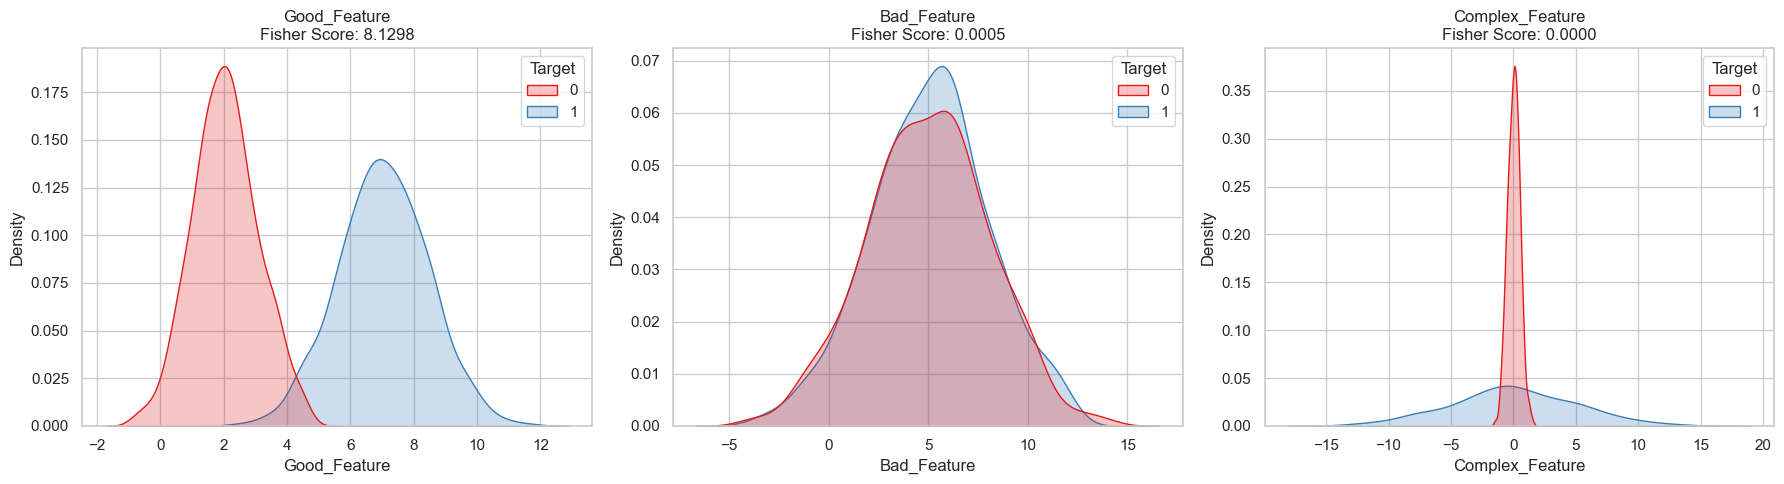


--- OBSERVATIONS ---
1. Good Feature: Massive separation between the red and blue peaks (high numerator), resulting in a high score.
2. Bad Feature: The distributions perfectly overlap. The means are the same, so the numerator is ~0. Score is near zero.
3. Complex Feature (Limitation): The Fisher Score is near ZERO. Even though the distributions are clearly different (red is tight, blue is widespread), their *means* are identical. Fisher Score assumes separation relies on differing means, making it blind to this specific type of predictive signal.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features):
    sns.kdeplot(data=df, x=feature, hue='Target', fill=True, ax=axes[i], palette='Set1', alpha=0.25)
    axes[i].set_title(f"{feature}\nFisher Score: {scores[feature]:.4f}")

plt.tight_layout()
plt.show()

print("\n--- OBSERVATIONS ---")
print("1. Good Feature: Massive separation between the red and blue peaks (high numerator), resulting in a high score.")
print("2. Bad Feature: The distributions perfectly overlap. The means are the same, so the numerator is ~0. Score is near zero.")
print("3. Complex Feature (Limitation): The Fisher Score is near ZERO. Even though the distributions are clearly different "
      "(red is tight, blue is widespread), their *means* are identical. Fisher Score assumes separation relies on differing means, "
      "making it blind to this specific type of predictive signal.")